# Préparation des features — Maintenance prédictive (Gold Dataset) — variante : CV calendaire

**Contexte technique** : Python, pandas, pyarrow, scikit-learn. Installation des packages via `uv`.

**Fichier source** : `artifacts/ingestions/datas/gold_dataset.parquet`

Étapes :
1. Charger le parquet, trié par machine puis par temps
2. Exclure les colonnes de fuite, les identifiants et les labels des features
3. Choisir un horizon et construire la cible `y` (0/1)
4. Utiliser le split temporel fourni (`split_set` : train < validation < test)
5. Imputer les NaN (médiane) ; standardiser pour les modèles linéaires


In [1]:
# Installation des dépendances (si nécessaire)
# uv add ipykernel pandas jupyter xgboost   
# uv add pyarrow scikit-learn xgboost matplotlib seaborn

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)


## 1) Charger le parquet, trié par machine puis par temps

In [3]:
DATA_PATH = "artifacts/ingestions/datas/gold_dataset.parquet"

df = pd.read_parquet(DATA_PATH)
df = df.sort_values(["machine_id_std", "window_start"]).reset_index(drop=True)

print(df.shape)
df.head()


(134280, 100)


,machine_id_std,window_start,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,window_end,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d,future_incident_count_6h,label_failure_next_6h,future_incident_count_12h,label_failure_next_12h,future_incident_count_24h,label_failure_next_24h,future_incident_count_48h,label_failure_next_48h,split_set
0,MACH-01,2025-06-01 00:00:00,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,4,2025-06-01 01:00:00,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.921634,-0.642904,4,0.347222,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
1,MACH-01,2025-06-01 01:00:00,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,4,2025-06-01 02:00:00,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,NaN,NaN,NaN,NaN,0.707107,2.422,NaN,0.092,NaN,-3.927,NaN,-0.088,NaN,-0.340840,-0.598766,8,0.694444,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
2,MACH-01,2025-06-01 02:00:00,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,13,2025-06-01 03:00:00,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,NaN,NaN,NaN,NaN,1.010984,2.590,NaN,1.250,NaN,46.800,NaN,1.200,NaN,0.280242,0.000936,21,1.822917,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0.0,False,0.0,False,0.0,False,0.0,False,train
3,MACH-01,2025-06-01 03:00:00,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,10,2025-06-01 04:00:00,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000

## 2) Exclure les colonnes de fuite, les identifiants et les labels des features

- **Identifiants / temporel** : `machine_id_std`, `window_start`, `window_end`
- **Fuite de données (leakage)** : `future_incident_count_6h/12h/24h/48h` — comptent des incidents futurs, utilisés pour construire les labels
- **Labels** : `label_failure_next_6h/12h/24h/48h`
- **Split** : `split_set`


In [4]:
id_cols = ["machine_id_std", "window_start", "window_end"]

leakage_cols = [
    "future_incident_count_6h",
    "future_incident_count_12h",
    "future_incident_count_24h",
    "future_incident_count_48h",
]

label_cols = [
    "label_failure_next_6h",
    "label_failure_next_12h",
    "label_failure_next_24h",
    "label_failure_next_48h",
]

control_cols = ["split_set"]

exclude_cols = id_cols + leakage_cols + label_cols + control_cols

feature_cols = [c for c in df.columns if c not in exclude_cols]

# Garde-fou : aucune colonne "future_*" ne doit rester dans les features
assert not any(c.startswith("future_") for c in feature_cols), "Fuite détectée dans les features !"

X_all = df[feature_cols]
print(f"{len(feature_cols)} features conservées")
X_all.head()


88 features conservées


,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d
0,46.340,46.340,198.203,198.203,227.568,227.568,1541.787,1541.787,4,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,46.3400,46.340,NaN,198.2030,198.203,NaN,227.568000,227.568,NaN,1541.78700,1541.787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.921634,-0.642904,4,0.347222,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
1,48.762,48.762,198.295,198.295,227.480,227.480,1537.860,1537.860,4,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,47.5510,48.762,1.712613,198.2490,198.295,0.065054,227.524000,227.568,0.062225,1539.82350,1541.787,2.776808,NaN,NaN,NaN,NaN,0.707107,2.422,NaN,0.092,NaN,-3.927,NaN,-0.088,NaN,-0.340840,-0.598766,8,0.694444,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
2,51.352,51.352,199.545,199.545,228.680,228.680,1584.660,1584.660,13,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,48.8180,51.352,2.506469,198.6810,199.545,0.749659,227.909333,228.680,0.668866,1554.76900,1584.660,25.960725,NaN,NaN,NaN,NaN,1.010984,2.590,NaN,1.250,NaN,46.800,NaN,1.200,NaN,0.280242,0.000936,21,1.822917,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
3,49.512,49.512,201.641,201.641,228.440,228.440,1588.960,1588.960,10,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,48.9915,51.352,2.075733,199.4210,201.641,1.601580,228.042000,228.680,0.607170,1563.31675,1588.960,27.231641,NaN,NaN,NaN,NaN,0.250755,-1.840,3.172,2.096,3.438,4.300,47.173,-0.240,0.872,-0.160990,1.006515,31,2.690972,0.0,NaN,0.0,NaN,0.0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0
4,51.982,51.982,200.157,200.157,227.840,227.840,1548.660,1548.660,6,49.5896,51.982,2.240562,199.5682,201.641,1.425529,228.001600,228.680

## 3) Choisir un horizon et construire la cible y (0/1)

Quatre horizons disponibles : `label_failure_next_6h`, `label_failure_next_12h`, `label_failure_next_24h`, `label_failure_next_48h`.


In [5]:
for col in label_cols:
    print(f"{col}: {df[col].mean():.1%} positifs")


label_failure_next_6h: 4.5% positifs
label_failure_next_12h: 8.8% positifs
label_failure_next_24h: 16.8% positifs
label_failure_next_48h: 25.5% positifs


In [6]:
HORIZON = "label_failure_next_24h"  # <-- changer ici pour un autre horizon

y = df[HORIZON].astype(int)
y.value_counts(normalize=True)


label_failure_next_24h
0    0.832082
1    0.167918
Name: proportion, dtype: float64

## 4) Utiliser le split temporel fourni (pas de split aléatoire)

⚠️ Ne jamais utiliser `train_test_split(shuffle=True)` : cela romprait la chronologie et provoquerait une fuite d'information.


In [7]:
print(df["split_set"].value_counts())
print((df["split_set"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

train_mask = df["split_set"] == "train"
val_mask   = df["split_set"] == "validation"
test_mask  = df["split_set"] == "test"

X_train, y_train = X_all[train_mask], y[train_mask]
X_val,   y_val   = X_all[val_mask],   y[val_mask]
X_test,  y_test  = X_all[test_mask],  y[test_mask]

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

split_set
train         93990
test          20145
validation    20145
Name: count, dtype: int64
split_set
train         70.0 %
test          15.0 %
validation    15.0 %
Name: proportion, dtype: str
train: (93990, 88) val: (20145, 88) test: (20145, 88)


In [8]:
# Vérification : les plages temporelles ne doivent pas se chevaucher
for name, mask in [("train", train_mask), ("validation", val_mask), ("test", test_mask)]:
    print(name, df.loc[mask, "window_start"].min(), "->", df.loc[mask, "window_start"].max())


train 2025-06-01 00:00:00 -> 2026-02-17 01:00:00
validation 2026-02-17 02:00:00 -> 2026-04-14 00:00:00
test 2026-04-14 01:00:00 -> 2026-06-08 23:00:00


## 5) Imputer les NaN (médiane) ; standardiser pour les modèles linéaires

Règle impérative : fitter l'imputer/scaler **uniquement sur le train**, puis appliquer (`transform`) sur validation et test.


In [9]:
# Colonnes avec des NaN
na_counts = X_train.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)


incident_max_severity_1h          93264
incident_max_severity_prev_24h    78423
hours_since_last_incident          4028
days_since_last_maintenance        3446
rotation_trend_6h                  1224
rotation_delta_3h                   961
rotation_delta_1h                   762
rotation_mean_1h                    662
rotation_max_1h                     662
rotation_std_6h                     410
rotation_mean_6h                    249
rotation_max_6h                     249
voltage_trend_6h                     90
pressure_trend_6h                    90
temp_trend_6h                        90
rotation_std_12h                     68
pressure_delta_3h                    45
temp_delta_3h                        45
voltage_delta_3h                     45
temp_std_6h                          15
rotation_std_24h                     15
pressure_std_24h                     15
voltage_std_24h                      15
rotation_mean_12h                    15
rotation_max_12h                     15


In [10]:
# Imputation médiane — pour tous les modèles
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)

X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=feature_cols, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=feature_cols, index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols, index=X_test.index)

X_train_imp.isna().sum().sum(), X_val_imp.isna().sum().sum(), X_test_imp.isna().sum().sum()


(np.int64(0), np.int64(0), np.int64(0))

In [11]:
# Standardisation — nécessaire seulement pour les modèles linéaires (régression logistique, SVM...)
# Pas nécessaire pour les modèles à arbres (RandomForest, LightGBM, XGBoost)
scaler = StandardScaler()
scaler.fit(X_train_imp)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_imp), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_imp),   columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),  columns=feature_cols, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]]


,temp_mean_1h,temp_max_1h,pressure_mean_1h,pressure_max_1h,voltage_mean_1h,voltage_max_1h,rotation_mean_1h,rotation_max_1h,pieces_produced_sum_1h,temp_mean_6h,temp_max_6h,temp_std_6h,pressure_mean_6h,pressure_max_6h,pressure_std_6h,voltage_mean_6h,voltage_max_6h,voltage_std_6h,rotation_mean_6h,rotation_max_6h,rotation_std_6h,temp_mean_12h,temp_max_12h,temp_std_12h,pressure_mean_12h,pressure_max_12h,pressure_std_12h,voltage_mean_12h,voltage_max_12h,voltage_std_12h,rotation_mean_12h,rotation_max_12h,rotation_std_12h,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_max_24h,pressure_std_24h,voltage_mean_24h,voltage_max_24h,voltage_std_24h,rotation_mean_24h,rotation_max_24h,rotation_std_24h,temp_trend_6h,pressure_trend_6h,voltage_trend_6h,rotation_trend_6h,temp_zscore_24h,temp_delta_1h,temp_delta_3h,pressure_delta_1h,pressure_delta_3h,rotation_delta_1h,rotation_delta_3h,voltage_delta_1h,voltage_delta_3h,temp_zscore_machine,pressure_zscore_machine,pieces_produced_sum_24h,capacity_utilization_pct,incident_count_1h,incident_max_severity_1h,incident_count_prev_24h,incident_max_severity_prev_24h,incident_count_prev_7d,hours_since_last_incident,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite,type_surchauffe_count_prev_24h,type_baisse_pression_count_prev_24h,type_vibration_count_prev_24h,type_bruit_mecanique_count_prev_24h,type_surconsommation_count_prev_24h,type_blocage_mecanique_count_prev_24h,type_alarme_capteur_count_prev_24h,type_arret_urgence_count_prev_24h,type_defaut_qualite_count_prev_24h,days_since_last_maintenance,maintenance_count_prev_30d
mean,4.620531e-16,4.620531e-16,2.682811e-15,2.682811e-15,-1.741771e-16,-1.741771e-16,-3.241629e-15,-3.241629e-15,-1.257946e-16,-4.596340e-16,1.790153e-16,2.128831e-16,-1.824989e-14,7.983117e-16,1.935301e-17,2.612656e-15,8.534677e-15,1.451476e-16,-9.628122e-16,4.238309e-15,-2.322361e-16,1.006357e-15,-1.412770e-15,-3.870602e-17,1.034418e-14,1.854744e-14,-4.838252e-17,-1.625653e-15,3.135188e-15,9.676505e-17,-5.902668e-16,-2.445737e-15,2.322361e-16,-7.499291e-16,-1.528888e-15,0.000000,1.572432e-15,1.964814e-14,-1.935301e-16,-1.343099e-14,-1.877242e-15,-1.548241e-16,1.036354e-14,7.733947e-15,-3.870602e-17,-2.213123e-17,2.201783e-18,1.755756e-17,2.192333e-18,-2.237692e-17,1.087189e-17,-5.197342e-20,-9.858412e-18,-6.614798e-18,-4.233471e-18,5.745425e-18,4.554761e-18,-2.101616e-17,1.753867e-17,2.267931e-18,-1.161181e-16,9.434592e-17,6.047816e-18,-1.209563e-18,-2.902951e-17,3.386777e-17,-1.257946e-16,-5.805903e-17,1.209563e-18,-7.710965e-18,-3.326299e-18,3.326299e-18,0.000000,-7.559770e-19,1.013009e-17,1.965540e-18,-3.023908e-18,-2.419126e-17,-2.479604e-17,3.507733e-17,-2.419126e-17,-2.419126e-18,2.419126e-18,-2.902951e-17,-1.814345e-18,1.935301e-17,3.628689e-17,-9.676505e-18
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1

In [12]:
# Alternative : pipeline unique (évite les fuites par construction)
linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train_scaled_pipe = linear_pipeline.fit_transform(X_train)
X_val_scaled_pipe   = linear_pipeline.transform(X_val)
X_test_scaled_pipe  = linear_pipeline.transform(X_test)


## 6) Vérifier le taux de panne (rare) → ne pas utiliser l'accuracy

Les labels sont fortement déséquilibrés. Un modèle qui prédit toujours "pas de panne" obtient déjà une accuracy élevée sans aucune valeur prédictive.


In [13]:
print(f"Taux de panne (train) : {y_train.mean():.2%}")
print(f"Taux de panne (val)   : {y_val.mean():.2%}")
print(f"Taux de panne (test)  : {y_test.mean():.2%}")


Taux de panne (train) : 16.60%
Taux de panne (val)   : 17.24%
Taux de panne (test)  : 17.26%


⚠️ Ne pas piloter l'évaluation du modèle avec l'accuracy. Utiliser plutôt :
- **PR-AUC** (aire sous la courbe précision-rappel) — la plus informative sur classe rare
- **Recall** — capacité à détecter les vraies pannes
- **F1-score** — compromis précision/rappel
- **ROC-AUC** — utile mais moins discriminant que PR-AUC quand la classe positive est rare


In [14]:
from sklearn.metrics import average_precision_score, f1_score, recall_score, roc_auc_score

# à calculer sur les prédictions du modèle (y_pred / y_proba), une fois entraîné
# average_precision_score(y_test, y_proba)
# recall_score(y_test, y_pred)
# f1_score(y_test, y_pred)
# roc_auc_score(y_test, y_proba)


## 7) Compenser le déséquilibre des classes

Deux approches selon la bibliothèque utilisée, toutes deux calculées/appliquées **sur le train uniquement**.

### scikit-learn : `class_weight="balanced"`


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train_imp, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### XGBoost : `scale_pos_weight`

XGBoost n'a pas de `class_weight` : le ratio doit être calculé manuellement sur le train, comme `nb_négatifs / nb_positifs`.


In [16]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
xgb.fit(X_train_imp, y_train)


scale_pos_weight = 5.03


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

⚠️ `scale_pos_weight` doit être recalculé à chaque changement d'horizon, et toujours à partir de `y_train` uniquement — jamais de `y_val`/`y_test`.


## 8) Prédire sur le jeu de test et afficher les informations pertinentes

Pour chaque modèle entraîné (`log_reg`, `rf`, `xgb`), prédire sur `X_test` (ou `X_test_scaled` pour le modèle linéaire) et centraliser les métriques adaptées au déséquilibre (voir étape 6) plutôt que l'accuracy.


### 8.1 Prédictions (classe + probabilité)

In [17]:
# Régression logistique (features standardisées)
y_pred_log  = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest (features imputées, pas de standardisation nécessaire)
y_pred_rf  = rf.predict(X_test_imp)
y_proba_rf = rf.predict_proba(X_test_imp)[:, 1]

# XGBoost (features imputées)
y_pred_xgb  = xgb.predict(X_test_imp)
y_proba_xgb = xgb.predict_proba(X_test_imp)[:, 1]


### 8.2 Tableau récapitulatif des métriques (PR-AUC, ROC-AUC, precision, recall, F1)

In [18]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, recall_score, precision_score,
)

models_preds = {
    "LogisticRegression":  (y_pred_log, y_proba_log),
    "RandomForest":        (y_pred_rf,  y_proba_rf),
    "XGBoost":             (y_pred_xgb, y_proba_xgb),
}

rows = []
for name, (y_pred, y_proba) in models_preds.items():
    rows.append({
        "modele":     name,
        "pr_auc":     average_precision_score(y_test, y_proba),
        "roc_auc":    roc_auc_score(y_test, y_proba),
        "precision":  precision_score(y_test, y_pred),
        "recall":     recall_score(y_test, y_pred),
        "f1":         f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(rows).set_index("modele").round(3)
results_df


,pr_auc,roc_auc,precision,recall,f1
modele,,,,,
LogisticRegression,0.577,0.762,0.554,0.544,0.549
RandomForest,0.613,0.767,0.865,0.375,0.523
XGBoost,0.579,0.745,0.614,0.478,0.537


### 8.3 Matrice de confusion par modèle

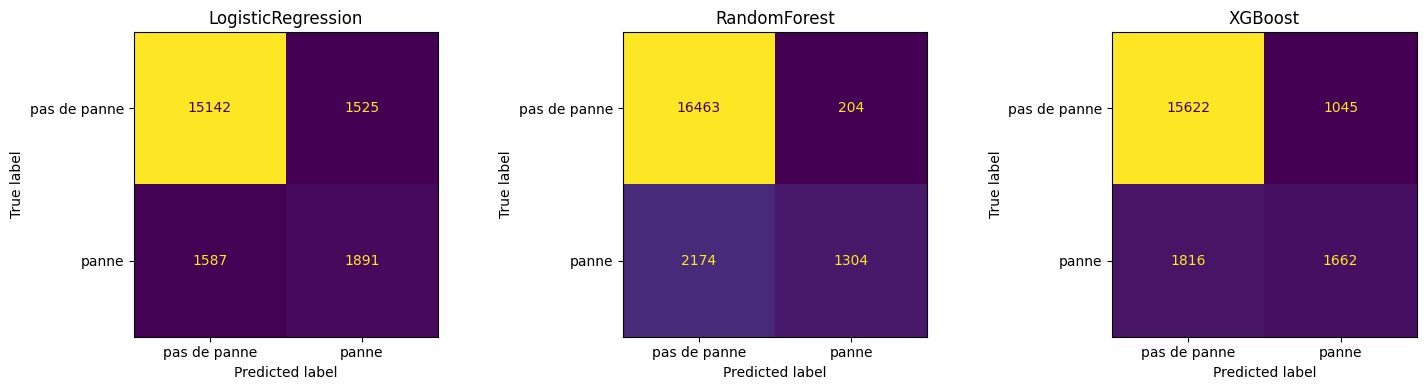

LogisticRegression: somme de la matrice de confusion = 20145 (taille de y_test = 20145)
RandomForest: somme de la matrice de confusion = 20145 (taille de y_test = 20145)
XGBoost: somme de la matrice de confusion = 20145 (taille de y_test = 20145)


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (y_pred, _)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["pas de panne", "panne"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Somme des éléments de chaque matrice de confusion (doit être égale à len(y_test))
for name, (y_pred, _) in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name}: somme de la matrice de confusion = {cm.sum()} (taille de y_test = {len(y_test)})")


### 8.4 Courbe précision-rappel (comparaison des modèles)

Plus informative que la ROC quand la classe positive est rare.

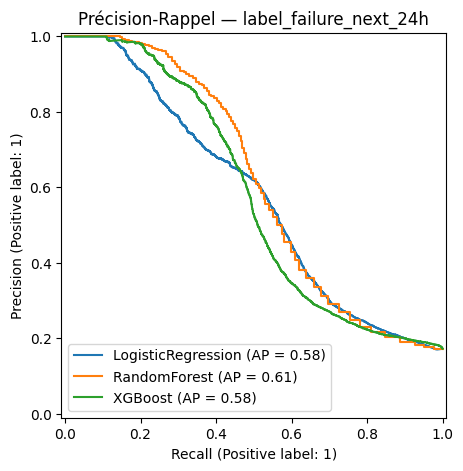

In [20]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, (_, y_proba) in models_preds.items():
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
ax.set_title(f"Précision-Rappel — {HORIZON}")
plt.show()


### 8.5 Rapport de classification détaillé

In [21]:
from sklearn.metrics import classification_report

for name, (y_pred, _) in models_preds.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["pas de panne", "panne"]))


--- LogisticRegression ---
              precision    recall  f1-score   support

pas de panne       0.91      0.91      0.91     16667
       panne       0.55      0.54      0.55      3478

    accuracy                           0.85     20145
   macro avg       0.73      0.73      0.73     20145
weighted avg       0.84      0.85      0.84     20145

--- RandomForest ---


              precision    recall  f1-score   support

pas de panne       0.88      0.99      0.93     16667
       panne       0.86      0.37      0.52      3478

    accuracy                           0.88     20145
   macro avg       0.87      0.68      0.73     20145
weighted avg       0.88      0.88      0.86     20145

--- XGBoost ---
              precision    recall  f1-score   support

pas de panne       0.90      0.94      0.92     16667
       panne       0.61      0.48      0.54      3478

    accuracy                           0.86     20145
   macro avg       0.75      0.71      0.73     20145
weighted avg       0.85      0.86      0.85     20145



### 8.6 Importance des features (modèles à arbres)

Utile pour interpréter ce qui pilote la prédiction (Random Forest / XGBoost uniquement).

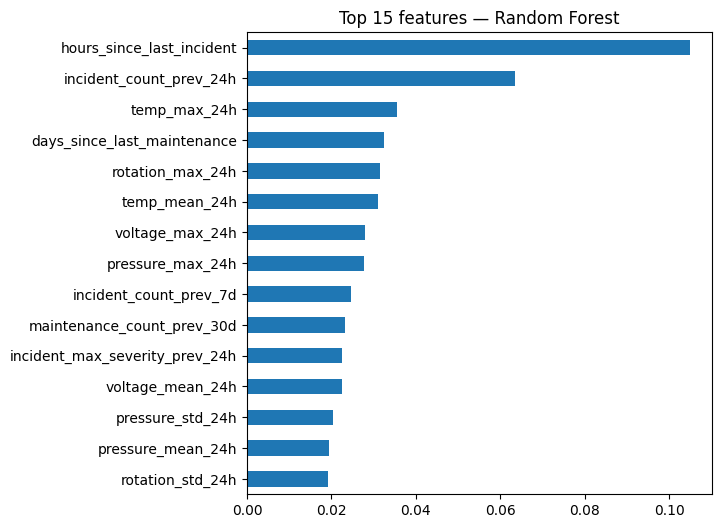

In [22]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot.barh(figsize=(6, 6), title="Top 15 features — Random Forest")
plt.gca().invert_yaxis()
plt.show()


⚠️ Toutes les métriques et graphiques de cette étape doivent être calculés sur `X_test` / `y_test`, jamais sur le train (qui a servi à l'entraînement) ni sur la validation (réservée au tuning des hyperparamètres/du seuil).

## 9) Lister et choisir les métriques associées aux données

Avant de figer les métriques utilisées aux étapes 6 et 8, il est utile de lister systématiquement les métriques de classification disponibles dans scikit-learn et de choisir celles pertinentes en fonction des caractéristiques des données (classes déséquilibrées, coût métier d'un faux négatif vs faux positif).


### 9.1 Lister les métriques de classification disponibles dans scikit-learn

In [23]:
import sklearn.metrics

# Liste des scorers nommés disponibles (utilisables via scoring="..." dans cross_val_score, GridSearchCV, etc.)
sorted(sklearn.metrics.get_scorer_names())


['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

### 9.2 Grille de choix selon les caractéristiques des données

| Caractéristique des données | Métrique(s) recommandée(s) | À éviter |
|---|---|---|
| Classes déséquilibrées (ici : 4.5 % à 25.5 % de positifs) | PR-AUC (`average_precision`), F1, recall | Accuracy |
| Faux négatif coûteux (panne manquée) | Recall, F2-score (pondère le recall) | Precision seule |
| Faux positif coûteux (fausse alerte, intervention inutile) | Precision, F0.5-score | Recall seul |
| Besoin d'un score continu pour prioriser (ranking des machines à risque) | PR-AUC, ROC-AUC | Métriques à seuil fixe (F1, recall à 0.5) |
| Comparaison de plusieurs modèles/horizons sur un même graphique | Courbe précision-rappel, ROC | — |
| Communication à un public non technique | Matrice de confusion, rapport de classification | AUC brute (moins intuitive) |


### 9.3 Sélectionner et calculer les métriques choisies pour ce projet

Sur la base de la grille ci-dessus (classes rares + coût métier orienté détection des pannes) :


In [24]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score, fbeta_score,
)

selected_metrics = {
    "pr_auc":    lambda y_true, y_pred, y_proba: average_precision_score(y_true, y_proba),
    "roc_auc":   lambda y_true, y_pred, y_proba: roc_auc_score(y_true, y_proba),
    "precision": lambda y_true, y_pred, y_proba: precision_score(y_true, y_pred),
    "recall":    lambda y_true, y_pred, y_proba: recall_score(y_true, y_pred),
    "f1":        lambda y_true, y_pred, y_proba: f1_score(y_true, y_pred),
    "f2":        lambda y_true, y_pred, y_proba: fbeta_score(y_true, y_pred, beta=2),  # priorise le recall
}

rows = []
for name, (y_pred, y_proba) in models_preds.items():
    row = {"modele": name}
    for metric_name, metric_fn in selected_metrics.items():
        row[metric_name] = metric_fn(y_test, y_pred, y_proba)
    rows.append(row)

pd.DataFrame(rows).set_index("modele").round(3)


,pr_auc,roc_auc,precision,recall,f1,f2
modele,,,,,,
LogisticRegression,0.577,0.762,0.554,0.544,0.549,0.546
RandomForest,0.613,0.767,0.865,0.375,0.523,0.423
XGBoost,0.579,0.745,0.614,0.478,0.537,0.500


⚠️ Le F2-score (recall pondéré 2x plus que la precision) est pertinent ici si le coût métier d'une panne manquée est plus élevé que celui d'une fausse alerte — à ajuster (`beta`) selon le contexte métier réel.

## 10) Validation croisée temporelle par découpage calendaire (indépendant de l'ordre des lignes)

Contrairement à `TimeSeriesSplit` (qui s'appuie sur la **position** des lignes dans le tableau), cette approche découpe l'intervalle de dates du train en segments **calendaires** fixes, via des comparaisons directes sur `window_start`. Chaque fold est défini par une date de coupure — train/validation restent strictement séparés dans le temps, quel que soit l'ordre des machines dans le DataFrame.


### 10.1 Définir les bornes calendaires

In [25]:
N_SPLITS = 5
n_chunks = N_SPLITS + 1  # nombre de segments calendaires nécessaires pour N_SPLITS folds expansifs

train_dates = df.loc[train_mask, "window_start"]
date_min, date_max = train_dates.min(), train_dates.max()

# n_chunks+1 bornes -> n_chunks segments calendaires égaux
boundaries = pd.date_range(date_min, date_max, periods=n_chunks + 1)
boundaries


DatetimeIndex(['2025-06-01 00:00:00', '2025-07-14 12:10:00',
               '2025-08-27 00:20:00', '2025-10-09 12:30:00',
               '2025-11-22 00:40:00', '2026-01-04 12:50:00',
               '2026-02-17 01:00:00'],
              dtype='datetime64[us]', freq=None)

### 10.2 Construire et évaluer les folds (fenêtre expansive, imputer refitté par fold)

Refitter l'imputer à l'intérieur de chaque fold (sur son train uniquement) évite toute fuite d'information entre folds — plus rigoureux que réutiliser l'imputer global du train.

In [26]:
from sklearn.base import clone

cv_rows = []
for fold in range(N_SPLITS):
    cutoff_train_end = boundaries[fold + 1]
    cutoff_val_end   = boundaries[fold + 2]

    fold_train_mask = train_mask & (df["window_start"] < cutoff_train_end)
    fold_val_mask   = train_mask & (df["window_start"] >= cutoff_train_end) & (df["window_start"] < cutoff_val_end)

    X_tr_raw, y_tr = X_all[fold_train_mask], y[fold_train_mask]
    X_va_raw, y_va = X_all[fold_val_mask],   y[fold_val_mask]

    fold_imputer = SimpleImputer(strategy="median")
    X_tr = fold_imputer.fit_transform(X_tr_raw)
    X_va = fold_imputer.transform(X_va_raw)

    model = clone(rf)
    model.fit(X_tr, y_tr)

    y_va_pred  = model.predict(X_va)
    y_va_proba = model.predict_proba(X_va)[:, 1]

    cv_rows.append({
        "fold": fold + 1,
        "train_end": cutoff_train_end,
        "val_end": cutoff_val_end,
        "n_train": int(fold_train_mask.sum()),
        "n_val": int(fold_val_mask.sum()),
        "n_machines_train": df.loc[fold_train_mask, "machine_id_std"].nunique(),
        "n_machines_val": df.loc[fold_val_mask, "machine_id_std"].nunique(),
        "taux_panne_train": y_tr.mean(),
        "taux_panne_val": y_va.mean(),
        "pr_auc": average_precision_score(y_va, y_va_proba),
        "roc_auc": roc_auc_score(y_va, y_va_proba),
        "recall": recall_score(y_va, y_va_pred),
        "f1": f1_score(y_va, y_va_pred),
    })

cv_df = pd.DataFrame(cv_rows).set_index("fold")
cv_df.round(3)


/tmp/ipykernel_615/2756123312.py:41: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  cv_df.round(3)


,train_end,val_end,n_train,n_val,n_machines_train,n_machines_val,taux_panne_train,taux_panne_val,pr_auc,roc_auc,recall,f1
fold,,,,,,,,,,,,
1,2025-07-14 12:10:00,2025-08-27 00:20:00,15675,15660,15,15,0.167,0.180,0.527,0.760,0.256,0.380
2,2025-08-27 00:20:00,2025-10-09 12:30:00,31335,15660,15,15,0.174,0.201,0.649,0.795,0.417,0.559
3,2025-10-09 12:30:00,2025-11-22 00:40:00,46995,15660,15,15,0.183,0.111,0.430,0.743,0.314,0.421
4,2025-11-22 00:40:00,2026-01-04 12:50:00,62655,15660,15,15,0.165,0.178,0.594,0.745,0.379,0.528
5,2026-01-04 12:50:00,2026-02-17 01:00:00,78315,15660,15,15,0.168,0.158,0.620,0.780,0.359,0.513


### 10.3 Garde-fou : aucun fold vide, aucun chevauchement

In [27]:
for fold in range(N_SPLITS):
    row = cv_df.loc[fold + 1]
    assert row["n_train"] > 0 and row["n_val"] > 0, f"Fold {fold + 1} vide — ajuster N_SPLITS ou les bornes calendaires"

print("Tous les folds sont non-vides ; train/validation strictement séparés par date de coupure.")


Tous les folds sont non-vides ; train/validation strictement séparés par date de coupure.


### 10.4 Résumé (moyenne ± écart-type)

In [28]:
summary = cv_df[["pr_auc", "roc_auc", "recall", "f1"]].agg(["mean", "std"]).round(3)
summary


,pr_auc,roc_auc,recall,f1
mean,0.564,0.765,0.345,0.480
std,0.087,0.022,0.062,0.076


### 10.5 Couverture des machines par fold

Un découpage calendaire n'assure pas une répartition égale des machines entre folds (si certaines machines n'ont des données que sur une partie de la période). Vérifier cette couverture.

In [29]:
cv_df[["n_train", "n_val", "n_machines_train", "n_machines_val"]]


,n_train,n_val,n_machines_train,n_machines_val
fold,,,,
1,15675,15660,15,15
2,31335,15660,15,15
3,46995,15660,15,15
4,62655,15660,15,15
5,78315,15660,15,15


### 10.6 Frise temporelle des folds

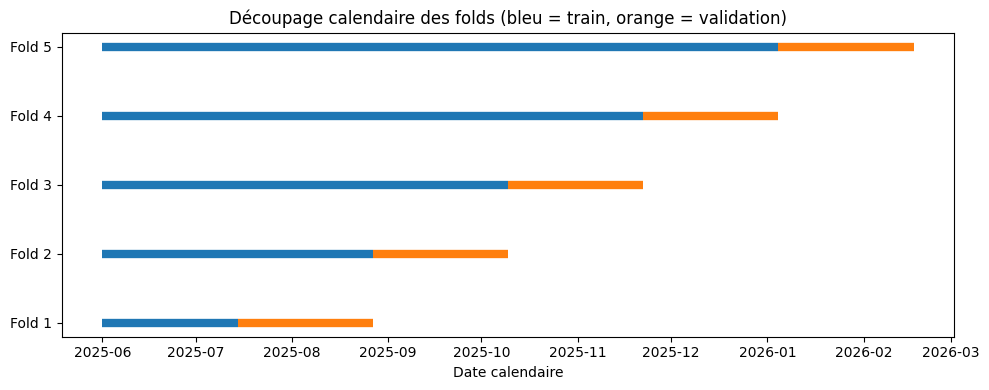

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
for fold in range(N_SPLITS):
    row = cv_df.loc[fold + 1]
    ax.plot([date_min, row["train_end"]], [fold, fold], color="tab:blue", linewidth=6, solid_capstyle="butt")
    ax.plot([row["train_end"], row["val_end"]], [fold, fold], color="tab:orange", linewidth=6, solid_capstyle="butt")
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i + 1}" for i in range(N_SPLITS)])
ax.set_xlabel("Date calendaire")
ax.set_title("Découpage calendaire des folds (bleu = train, orange = validation)")
plt.tight_layout()
plt.show()


### 10.7 Évolution des métriques dans le temps

Axe des abscisses en dates réelles (et non en numéro de fold) pour repérer une dérive calendaire (ex. : saisonnalité, dégradation progressive).

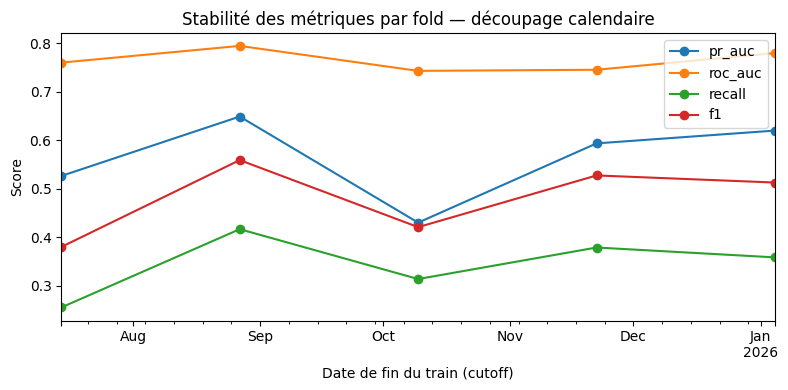

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
cv_df.set_index("train_end")[["pr_auc", "roc_auc", "recall", "f1"]].plot(marker="o", ax=ax)
ax.set_xlabel("Date de fin du train (cutoff)")
ax.set_ylabel("Score")
ax.set_title("Stabilité des métriques par fold — découpage calendaire")
plt.tight_layout()
plt.show()


⚠️ Différences clés avec l'approche `TimeSeriesSplit` positionnelle :
- Les bornes sont des **dates**, pas des index de lignes → chaque fold couvre une période calendaire identique pour toutes les machines, sans effet d'entrelacement lié au tri par `machine_id_std`.
- L'imputer est refitté à chaque fold (pas de réutilisation de l'imputer global du train) → estimation moins optimiste.
- Si une machine n'a des données que sur une sous-période, elle peut être absente de certains folds (voir 10.5) — à surveiller si l'objectif est une performance par machine.


## Résumé

- `X_train_imp / X_val_imp / X_test_imp` : features imputées (médiane), utilisables directement pour les modèles à arbres
- `X_train_scaled / X_val_scaled / X_test_scaled` : features imputées + standardisées, pour les modèles linéaires
- `y_train / y_val / y_test` : cible binaire pour l'horizon `HORIZON` choisi
- Modèles entraînés avec compensation du déséquilibre : `log_reg`, `rf` (`class_weight="balanced"`), `xgb` (`scale_pos_weight`)
- `results_df` : tableau comparatif PR-AUC / ROC-AUC / precision / recall / F1 sur le test
- Métriques choisies selon les caractéristiques des données (déséquilibre, coût métier) : PR-AUC, recall, F1, F2
- `cv_df` : estimation robuste par validation croisée **calendaire** (bornes sur `window_start`, imputer refitté par fold)

Pour tester un autre horizon, changer `HORIZON` à l'étape 3 et relancer les cellules suivantes.